# SIFT - Harris
### SIFT - Harris


maximum_filter:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.maximum_filter.html
gaussian_filter:https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.filters.gaussian_filter.html
sobel:https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.sobel.html

matplotlib.patches: https://matplotlib.org/api/patches_api.html

np.where: https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.where.html
np.argwhere: https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.argwhere.html

In [1]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

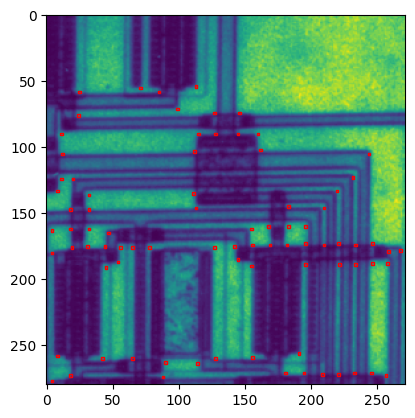

In [37]:
from skimage.filters import gaussian
from scipy.ndimage import maximum_filter,gaussian_filter,sobel
import matplotlib.patches as patches

eps=1e-6
img = io.imread('circuit.tif').astype(float)

# TODO perform gaussian_filter, this will make the image less noisy not a step in the Harris algorithm
blurred = gaussian_filter(img, sigma=1)

# TODO perform sobel to get x-change and y-change
Ix = sobel(blurred, axis=1)
Iy = sobel(blurred, axis=0)

# In the following 3 TODOs, we are using a guassian as our window function. 
# We could have just used an averaging filter.
# TODO perform gaussian_filter on x-change * x-change to get sum of Ixx (i.e Sx2)
Sx2 = gaussian_filter(Ix**2, sigma=1.5)
# TODO perform gaussian_filter on x-change * y-change to get sum of Ixy (i.e Sxy)
Sxy = gaussian_filter(Ix * Iy, sigma=1.5)
# TODO perform gaussian_filter on y-change * y-change to get sum of Iyy (i.e Sy2)
Sy2 = gaussian_filter(Iy**2, sigma=1.5)

# TODO Get R value using the supplied equations (use **2 for power 2)
det_M = Sx2 * Sy2 - Sxy**2
trace_M = Sx2 + Sy2
R = det_M / (trace_M + eps)

# TODO Get the R values which are local maximum and above a given threshold. 
# The maximum_filter will help you get the max value in a neighborhood.
threshold = 0.3 * R.max()
R_max = maximum_filter(R, size=15)
z = (R == R_max) & (R > threshold)

# From here we will assume that z is a binary mask where 1 means there is a corner
# This part will get the indices of z where z = true, then we will draw a small rectangle around those indices
indx = np.argwhere(z==True)

fig,ax = plt.subplots(1)
ax.imshow(img)

for ind in indx:
    rect = patches.Rectangle((ind[1],ind[0]),2,2,linewidth=1,edgecolor='r',facecolor='none')
    ax.add_patch(rect)
plt.show()

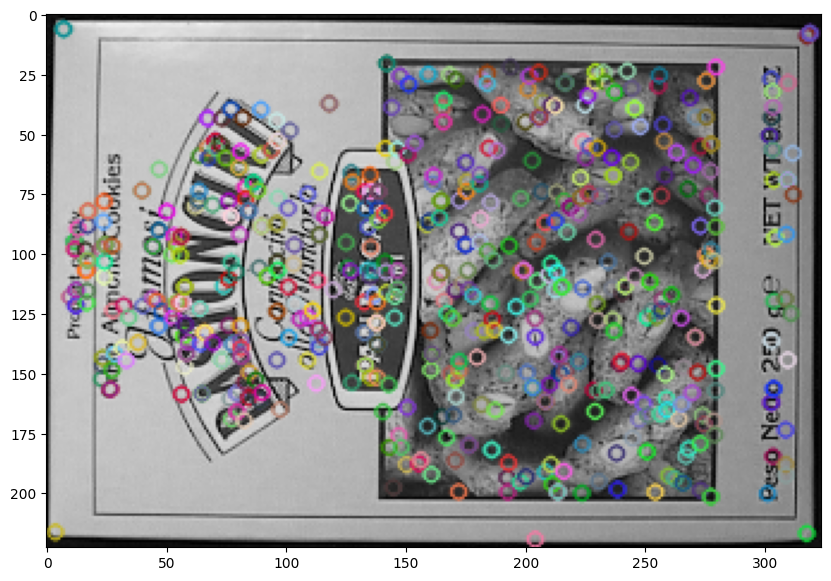

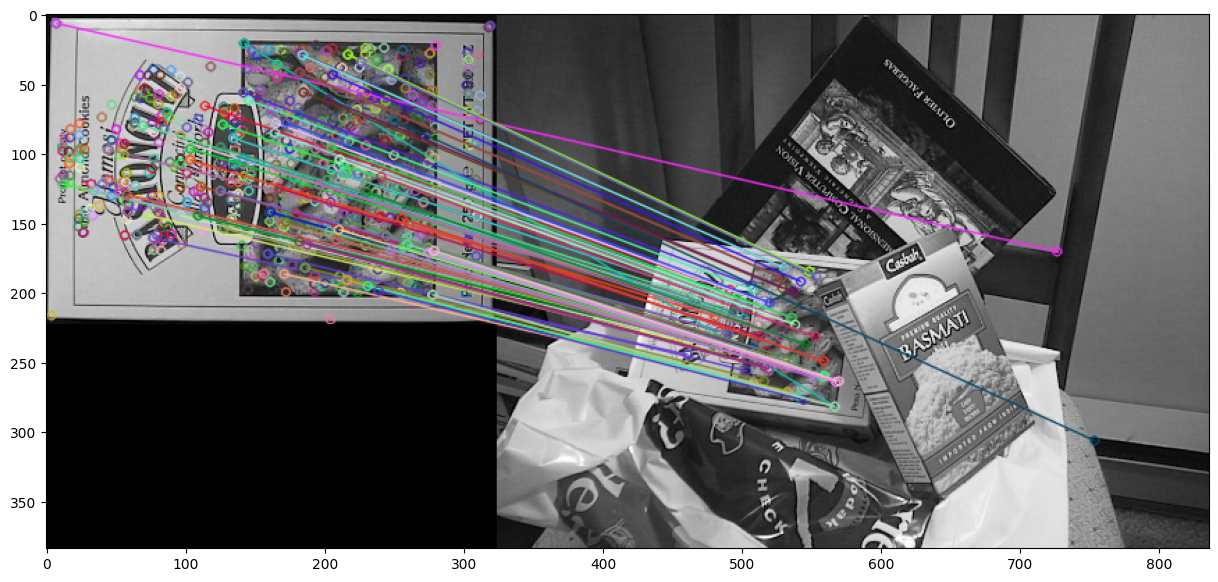

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

sift = cv2.xfeatures2d.SIFT_create()

## TODO: read image box.png and box_in_scene
img1 = cv2.imread('box.png')
img2 = cv2.imread('box_in_scene.png')
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

## TODO: find the keypoints and descriptors with SIFT
# Use sift.detectAndCompute
kp1, des1 = sift.detectAndCompute(img1_gray, None)
kp2, des2 = sift.detectAndCompute(img2_gray, None)

#Draw keypoints of img1 using cv2.drawKeypoints
img1_kp = cv2.drawKeypoints(img1_gray, kp1, img1)
plt.figure(figsize=(10, 8))
plt.imshow(img1_kp)
plt.show()

## TODO: Construct BFMatcher, Hint use cv2.BFMatcher
## Use knnMatch with k = 2 to get the matches between the descriptors 
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

## TODO: Apply ratio test to remove ambigiuous matched (points that has multiple matches)
## Hint: use the distance in match 
## For k=2 knnMatch return the 2 closest matches anyways.
## if the distance between the keypoints and its 2 neighbours is close, then the keypoint is ambigious and 
## you should neglect it
good_matches = []
for match_pair in matches:
    if len(match_pair) == 2:
        m, n = match_pair
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

## TODO: Draw the matches features use cv2.drawMatchesKnn with flags =4 
img3 = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(15, 10))
plt.imshow(img3)
plt.show()